KNN model pipeline's score: 73.96%, cross_validation_score: 73.57%
Logr model pipeline's score: 79.69%, cross_validation_score: 77.09%
DT model pipeline's score: 76.04%, cross_validation_score: 73.7%
RFC model pipeline's score: 77.08%, cross_validation_score: 76.31%


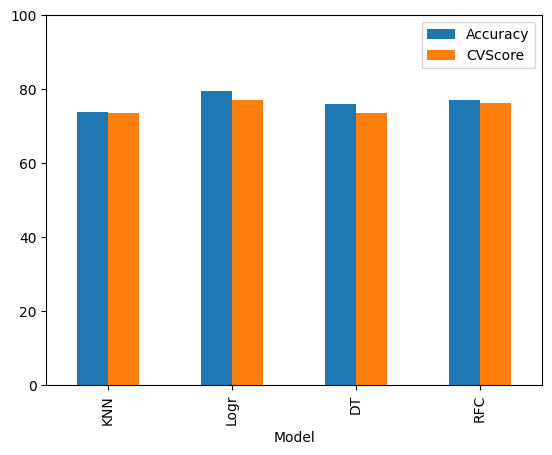

Best model: Logr


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline

df=pd.read_csv('diabetes.csv')
x=df.iloc[:,:-1]
y=df.iloc[:,-1]

x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=12,test_size=0.25)#ik it is default
pipe1=make_pipeline(StandardScaler(),KNeighborsClassifier(n_neighbors=5))
pipe2=make_pipeline(StandardScaler(),LogisticRegression(random_state=12))
pipe3=make_pipeline(StandardScaler(),DecisionTreeClassifier(random_state=12,max_depth=2))
pipe4=make_pipeline(StandardScaler(),RandomForestClassifier(random_state=12,max_depth=5))
pipes={
    "KNN":pipe1,
    'Logr':pipe2,
    'DT':pipe3,
    'RFC':pipe4
}
scores=[]
cvscores=[]
for name,pipe in pipes.items():
    score=round(pipe.fit(x_train,y_train).score(x_test,y_test)*100,2)
    cvscore=round(cross_val_score(pipe,x,y,cv=5).mean()*100,2)
    print(f"{name} model pipeline's score: {score}%, cross_validation_score: {cvscore}%")
    scores.append(score)
    cvscores.append(cvscore)

outputs=pd.DataFrame({
    'Model':pipes.keys(),
    'Accuracy':scores,
    'CVScore':cvscores
})
outputs.plot(kind='bar',x='Model',y=['Accuracy','CVScore'],rot=90)
plt.ylim(0,100)
plt.show()
best_idx=outputs['CVScore'].idxmax()
print(f"Best model: {outputs.loc[best_idx,'Model']}")